In [8]:
import numpy as np

from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current

from pybatteryse.filters import ParticleFilter
from pybatteryse.plotter import plot_time_vs_soc

from data import helper

### Load identified model and test dataset

In [9]:
model = load_model_from_file('data/nmc_with_temperature/model_n,l=3,3.npy')
dataset = helper.load_npy_datasets(f'data/nmc_with_temperature/validation_cold.npy')
bad_current_data = np.load(f'data/nmc_with_temperature/validation_cold_automotivecurrent.npy', allow_pickle=True).item()

Here we use bad current sensor values with large bias.

In [10]:
current_values = bad_current_data['current_values']
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']

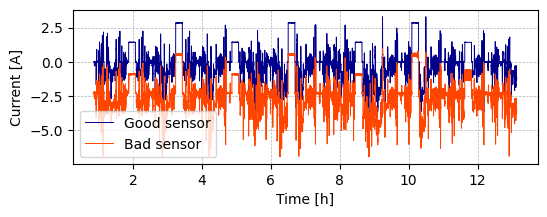

In [11]:
plot_time_vs_current([(dataset['time_values'] / 3600, dataset['current_values']),
                      (dataset['time_values'] / 3600, bad_current_data['current_values'][:len(dataset['time_values'])])],
                      units=('h', 'A'), colors=('darkblue', 'orangered'), legends=['Good sensor', 'Bad sensor'])

### Load particle filter and run it on the dataset

In [12]:
pf = ParticleFilter(model, num_particles=5, eta_bounds=(-4, -1), sigma_ny_ne=1e-3)

initial_particles = np.hstack((
    np.random.uniform(0.0001, 0.9999, size=(pf.num_particles, 1)),
    np.zeros((pf.num_particles, model.model_order))
))

state_estimates = pf.run(initial_particles=initial_particles,
                         temperature_values=temperature_values,
                         current_values=current_values,
                         voltage_values=voltage_values)

soc_estimates = state_estimates[:, 0]

PF Progress: 100%|████████████████████████████████████████| 44188/44188 [00:35<00:00, 1243.09step/s]


### Calculate true SOC

We calculate true SOC using coulomb counting with good-quality current measurements

In [13]:
# Coulomb counting method to calculate true SOC
soc_true = np.zeros(len(dataset['time_values']))
# True initial SOC
soc_true[0] = invert_voltage_function(model.emf_function, dataset['voltage_values'][0])

for k in range(1, len(dataset['time_values'])):
    soc_true[k] = soc_true[k - 1] + (dataset['current_values'][k] * model.sampling_period) / model.battery_capacity

### Plot estimated vs true SOC

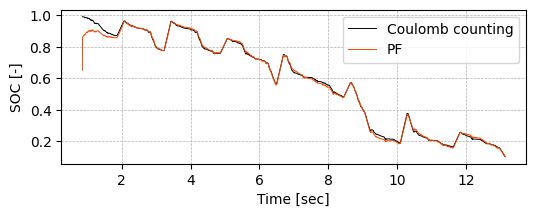

In [14]:
plot_time_vs_soc([(dataset['time_values'] / 3600, soc_true),
                  (dataset['time_values'] / 3600, soc_estimates)],
                  colors=('k', 'orangered'), legends=['Coulomb counting', 'PF'])